# Parameters from Gaussian Mixture Model

## Used libraries

In [1]:
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import random

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
main_path = '/content/drive/MyDrive/AzONet_New_145'

## Seaborn

In [4]:
# Set style first
sns.set_style("whitegrid")

# Then customize individual elements through rcParams
plt.rcParams.update({
    "figure.dpi": 300,           # Default DPI for new figures
    "savefig.dpi": 300,          # DPI when saving figures

    # Font settings
    "font.family": "sans-serif",     # Universal font family
    "font.size": 11,                   # Base font size

    # Title and label sizes
    "axes.titlesize": 16,             # Axis title size
    "axes.titleweight": "bold",       # Axis title weight
    "axes.labelsize": 14,             # Axis label size
    "axes.labelweight": "semibold",   # Axis label weight

    # -------------------------------------------------

    # Tick LABEL sizes (text next to ticks)
    "xtick.labelsize": 11,       # Size of x-axis tick labels (e.g., "0", "1", "2")
    "ytick.labelsize": 11,       # Size of y-axis tick labels

    # Tick MARK sizes (physical marks on axes)
    "xtick.major.size": 6,       # Length of MAJOR tick marks on x-axis
    "ytick.major.size": 6,       # Length of MAJOR tick marks on y-axis

    # Additional tick parameters you might want to use:
    "xtick.minor.size": 3,       # Length of MINOR tick marks on x-axis
    "ytick.minor.size": 3,       # Length of MINOR tick marks on y-axis

    # Tick WIDTH (thickness)
    "xtick.major.width": 1,      # Width/Thickness of major ticks
    "ytick.major.width": 1,      # Width/Thickness of major ticks

    # Tick PADDING (distance from label to tick)
    "xtick.major.pad": 3.5,      # Padding between x-tick and label
    "ytick.major.pad": 3.5,      # Padding between y-tick and label

    # Tick DIRECTIONS
    "xtick.direction": "out",    # "in", "out", or "inout"
    "ytick.direction": "out",    # Points outward from axis

    # Tick COLORS
    "xtick.color": "black",      # Color of x-axis ticks and labels
    "ytick.color": "black",      # Color of y-axis ticks and labels

    # MINOR ticks (for more granular scales)
    "xtick.minor.visible": False,  # Show minor x-ticks
    "ytick.minor.visible": False,  # Show minor y-ticks

    # BOTTOM/TOP/LEFT/RIGHT ticks (which sides get ticks)
    "xtick.top": False,          # Show ticks on top of plot
    "xtick.bottom": True,        # Show ticks on bottom (default: True)
    "ytick.left": True,          # Show ticks on left (default: True)
    "ytick.right": False,        # Show ticks on right

    # ---------------------------------

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 12,
    "legend.framealpha":0.9,

    # Figure title (for suptitle)
    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    # ----------------------------------

    # Figure border
    #"figure.edgecolor": "black",
    #"figure.frameon": True,
    #"figure.linewidth": 2.0,

    # Axes borders (spines)
    "axes.linewidth": 1.0,           # Width of axis lines
    "axes.edgecolor": "black",       # Color of axis lines

    # Individual spine control via rcParams
    "axes.spines.top": True,
    "axes.spines.bottom": True,
    "axes.spines.left": True,
    "axes.spines.right": True,

    # ----------------------------
    # Patch properties (for histograms, bars, kde fills, etc.)
    "patch.linewidth": 1.5,           # Default linewidth for patches
    "patch.edgecolor": "black",       # Default edge color
    "patch.facecolor": "blue",        # Default fill color (careful with this!)
    "patch.force_edgecolor": True,    # Always show edges

    "axes.grid": False,           # Turn off grid completely

})

## Bin to simulate from

In [5]:
bint = 4

In [6]:
table_data = []

## Main Data

In [7]:
param = np.load(main_path + '/notebooks/2_de/bins/region_{}.npy'.format(bint))

In [8]:
param.shape

(34, 12)

In [9]:
param[0]

array([1.10278717e+03, 3.93880800e+01, 1.96729072e+01, 3.24050201e+00,
       1.83310465e+06, 2.74938514e+06, 5.00483224e-01, 3.21008484e+02,
       3.59729387e-03, 1.05661446e+01, 3.62634654e+02, 2.14200242e+26])

## Gaussian Mixture Model

In [10]:
from sklearn.mixture import GaussianMixture

In [11]:
def GMM(data, max_gaussians: int = 10):
    data = data.reshape(-1, 1)

    bic_values = []
    n_components_range = range(1, max_gaussians+1) # Consider 10 Gaussians to Model it

    for n_components in n_components_range:
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=1360)
        gmm.fit(data)
        bic_values.append(gmm.bic(data))


    # Get the optimal number of components
    optimal_n_components = n_components_range[np.argmin(bic_values)]
    print(f"Óptimo número de componentes: {optimal_n_components}")

    # Fit the GMM with the optimal number of components
    gmm_optimal = GaussianMixture(n_components=optimal_n_components, covariance_type='full', random_state=1360)
    gmm_optimal.fit(data)


    # # Access the model parameters
    means = gmm_optimal.means_
    covariances = gmm_optimal.covariances_
    weights = gmm_optimal.weights_

    # Print the parameters
    print("Centroides:")
    print(means)
    print("\nCovarianzas")
    print(covariances)
    print("\nPesos")
    print(weights)

    # If you want to see if the model converged
    print("\nCovergencia:", gmm_optimal.converged_)


    #
    std_devs = np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))
    print('\nSTD:\n',std_devs)

    fwhm =  (2 * np.sqrt(2 * np.log(2) ) ) *  np.sqrt(np.diagonal(covariances, axis1=1, axis2=2))
    print('\nFWHM:\n',fwhm)

    table_data.append(
        [ means, std_devs, weights ]
    )

    return [
        #optimal_n_components,
        means,
        std_devs,
        #covariances,
        weights,
        np.min(data),
        np.max(data),
        gmm_optimal
    ]

In [12]:
def GMM_Model(t_values, means, std_devs, weights, min_value, max_value, score, n:int = 5000):

    _data = []
    for i in range(means.shape[0]):
        _data.append(np.random.normal( means[i], std_devs[i], int(n*weights[i])) )

    _data = np.concatenate(_data)
    if len(t_values) != 0:
        _data = _data[ _data>= t_values[0] ]
        _data = _data[ _data <= t_values[1] ]
    else:
        _data = _data[ _data>= min_value ]
        _data = _data[ _data <= max_value ]

    return _data, score


In [13]:
def GMM_pipeline(data, max_gaussians: int = 10, t_values = []):
    _dist = GMM(
        data= data,
        max_gaussians = max_gaussians,
    )

    simulated_data, gmm_optimal = GMM_Model(t_values, *_dist)

    return simulated_data

## Thickness

In [14]:
t_list = [100, 250, 600, 950, 1100, 1500]

In [15]:
thickness = GMM_pipeline(
    data = param[:, 0],
    max_gaussians= 3,
    t_values= [
        t_list[bint],
        t_list[bint+1]
    ]
    )

Óptimo número de componentes: 2
Centroides:
[[1207.28779083]
 [1420.61444471]]

Covarianzas
[[[2578.87887149]]

 [[1147.72715   ]]]

Pesos
[0.82429589 0.17570411]

Covergencia: True

STD:
 [[50.7826631]
 [33.878122 ]]

FWHM:
 [[119.58403301]
 [ 79.77688077]]


In [16]:
np.max(thickness), np.min(thickness)

(np.float64(1499.6792717778865), np.float64(1100.2071809688832))

In [17]:
table_data

[[array([[1207.28779083],
         [1420.61444471]]),
  array([[50.7826631],
         [33.878122 ]]),
  array([0.82429589, 0.17570411])]]

## R1

In [18]:
r1 = GMM_pipeline(
    data = param[:, 1],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[25.80970705]]

Covarianzas
[[[154.55514436]]]

Pesos
[1.]

Covergencia: True

STD:
 [[12.43202093]]

FWHM:
 [[29.27517208]]


In [19]:
table_data[1]

[array([[25.80970705]]), array([[12.43202093]]), array([1.])]

## R2

In [20]:
r2 = GMM_pipeline(
    data = param[:, 2],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[21.70708205]]

Covarianzas
[[[105.91643561]]]

Pesos
[1.]

Covergencia: True

STD:
 [[10.2915711]]

FWHM:
 [[24.23479791]]


In [21]:
pick_one = lambda x: np.random.choice(x) # This function inputs an array and returns a random element of that array

In [22]:
r1.shape, r2.shape

((4701,), (4613,))

## Absortion Coefficients

In [23]:
# Alpha
alpha = GMM_pipeline(
    data = param[:, 8],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[0.00779831]]

Covarianzas
[[[1.50736722e-05]]]

Pesos
[1.]

Covergencia: True

STD:
 [[0.00388248]]

FWHM:
 [[0.00914255]]


In [24]:
# beta
beta = GMM_pipeline(
    data = param[:, 9],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[10.83178989]
 [22.48787515]
 [ 9.11231715]]

Covarianzas
[[[1.53864378e+00]]

 [[1.00000000e-06]]

 [[3.50431938e-01]]]

Pesos
[0.14019485 0.02941176 0.83039338]

Covergencia: True

STD:
 [[1.24042081e+00]
 [1.00000000e-03]
 [5.91972920e-01]]

FWHM:
 [[2.92096778e+00]
 [2.35482005e-03]
 [1.39398970e+00]]


In [25]:
# lambda
lamda = GMM_pipeline(
    data = param[:, 10],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[354.43352046]]

Covarianzas
[[[43.19753065]]]

Pesos
[1.]

Covergencia: True

STD:
 [[6.57248284]]

FWHM:
 [[15.47701433]]


## Sellmeier Coefficients

The refractive index must be between $[1.8, 2.1]$, and the refractive index is given by:
$$n^{2}(\lambda) = A + \frac{B\lambda^{2}}{\lambda^{2} - C^{2}} + \frac{D\lambda^{2}}{\lambda^{2} - E^{2}}$$
Generate the Sellmeier Coefficients:

In [26]:
# A
A = GMM_pipeline(
    data = param[:, 3],
    max_gaussians= 3,
    )

Óptimo número de componentes: 3
Centroides:
[[3.24477266]
 [3.85496068]
 [3.41681538]]

Covarianzas
[[[2.90569848e-05]]

 [[1.00000000e-06]]

 [[9.56618278e-03]]]

Pesos
[0.80987164 0.0294117  0.16071666]

Covergencia: True

STD:
 [[0.00539045]
 [0.001     ]
 [0.09780686]]

FWHM:
 [[0.01269355]
 [0.00235482]
 [0.23031757]]


In [27]:
B = GMM_pipeline(
    data = param[:, 4],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[1603555.91159015]]

Covarianzas
[[[2.96436713e+11]]]

Pesos
[1.]

Covergencia: True

STD:
 [[544460.01960236]]

FWHM:
 [[1282105.36787757]]


In [28]:
C = GMM_pipeline(
    data = param[:, 5],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[2437140.16978228]
 [1094186.0185676 ]]

Covarianzas
[[[1.40717674e+11]]

 [[6.25066453e+10]]]

Pesos
[0.68642251 0.31357749]

Covergencia: True

STD:
 [[375123.54517449]
 [250013.29025531]]

FWHM:
 [[883348.44353995]
 [588736.30741735]]


In [29]:
D = GMM_pipeline(
    data = param[:, 6],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[0.50058681]
 [0.70518878]]

Covarianzas
[[[1.49058056e-06]]

 [[1.21025592e-02]]]

Pesos
[0.46919742 0.53080258]

Covergencia: True

STD:
 [[0.00122089]
 [0.11001163]]

FWHM:
 [[0.00287498]
 [0.2590576 ]]


In [30]:
E = GMM_pipeline(
    data = param[:, 7],
    max_gaussians= 3,
    )

Óptimo número de componentes: 2
Centroides:
[[320.15796381]
 [172.49950392]]

Covarianzas
[[[ 253.54037651]]

 [[1000.89870663]]]

Pesos
[0.88233877 0.11766123]

Covergencia: True

STD:
 [[15.92295125]
 [31.63698321]]

FWHM:
 [[37.49568478]
 [74.49940223]]


In [31]:
x = np.linspace(190e-9, 1101e-9, 911)

def refractive_index(x, A, B, C, D, E):

    n = np.sqrt(A + (B*x**2)/(x**2 - C**2 + 1e-6) + (D*x**2)/(x**2 - E**2 + 1e-6))  # Get the n
    #print(n.shape)

    return ( np.min(n), np.max(n) )


In [32]:
_A, _B, _C, _D, _E = pick_one(A), pick_one(B), pick_one(C), pick_one(D), pick_one(E)

_min, _max = refractive_index(x, _A, _B, _C, _D, _E)
_min, _max

(np.float64(1.8012034746057308), np.float64(1.8012034746057308))

The refractive is in the following range:
$$1.8 <  n < 2.1 $$

In [33]:
ABCDE = []

while len(ABCDE) < 3000:

    _A, _B, _C, _D, _E = pick_one(A), pick_one(B), pick_one(C), pick_one(D), pick_one(E)

    _min, _max = refractive_index(x, _A, _B, _C, _D, _E)[0] , refractive_index(x, _A, _B, _C, _D, _E)[1]

    if (_min >= 1.8 and  _max <= 2.1):
        ABCDE.append( (_A, _B, _C, _D, _E)  )

In [34]:
len(ABCDE)

3000

In [35]:
ABCDE = np.array(ABCDE)
ABCDE.shape

(3000, 5)

In [36]:
A, B, C, D, E = ABCDE.T
A.shape

(3000,)

## Ne

In [37]:
ne = GMM_pipeline(
    data = param[:, 11],
    max_gaussians= 3,
    )

Óptimo número de componentes: 1
Centroides:
[[1.23620296e+26]]

Covarianzas
[[[1.92854472e+51]]]

Pesos
[1.]

Covergencia: True

STD:
 [[4.39151992e+25]]

FWHM:
 [[1.03412391e+26]]


## Table

In [38]:
from prettytable import PrettyTable

In [39]:
names = ['r [nm]',
         r'$\sigma_{1} [nm]$', r'$\sigma_{2}$ [nm]',
         'A', 'B', 'C [nm]', 'D', 'E [nm]',
         r'$\alpha_{0}$ [nm]$^{-1}$', r'$\beta$ [eV]$^{-1}$', r'$\lambda_{g}$ [nm]',
         r'$n_{e}$ [nm]$^{-3}$',
        ]

In [40]:
table_data[1]

[array([[25.80970705]]), array([[12.43202093]]), array([1.])]

In [41]:
def to_str_good(array, pesos = False):
    txt = ''
    if pesos == False:
        if array.shape == (1,1):
            txt = '{:.3e}'.format(array[0, 0])
        elif array.shape == (2,1):
            txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}'.format(array[1, 0])
        else:
            txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}, '.format(array[1, 0]) + '{:.3e}'.format(array[2, 0])

    if pesos:
        if array.shape == (1,1):
            txt = '{:.1f}'.format(array[0, 0])
        elif array.shape == (2,1):
            txt = '{:.1f}, '.format(array[0, 0]) + '{:.1f}'.format(array[1, 0])
        else:
          txt = '{:.3e}, '.format(array[0, 0]) + '{:.3e}, '.format(array[1, 0]) + '{:.3e}'.format(array[2, 0])

    return txt

In [42]:
table_data = [
    table_data[0], # Espesor,
    table_data[1], # R1
    table_data[2], # R2
    table_data[6], #A,
    table_data[7], #B,
    table_data[8], #C,
    table_data[9], #D,
    table_data[10], #E,
    table_data[3], #Alpha,
    table_data[4], #Beta,
    table_data[5], #LambdaG,
    table_data[11], #ne
]

In [43]:
table = PrettyTable()

table.field_names = ["", r"Centroides $\mu_{i}$", r'Desviaciones $\delta_{i}$', r'Pesos $P_{i}$']

j = 0
for i in table_data:
    table.add_row([names[j],
                   to_str_good(i[0]),
                   to_str_good(i[1]),
                   to_str_good(np.expand_dims(i[2], axis = -1), pesos = True)
                  ]
                  )
    j +=1
print(table)


+--------------------------+---------------------------------+---------------------------------+---------------------------------+
|                          |       Centroides $\mu_{i}$      |    Desviaciones $\delta_{i}$    |          Pesos $P_{i}$          |
+--------------------------+---------------------------------+---------------------------------+---------------------------------+
|          r [nm]          |       1.207e+03, 1.421e+03      |       5.078e+01, 3.388e+01      |             0.8, 0.2            |
|    $\sigma_{1} [nm]$     |            2.581e+01            |            1.243e+01            |               1.0               |
|    $\sigma_{2}$ [nm]     |            2.171e+01            |            1.029e+01            |               1.0               |
|            A             | 3.245e+00, 3.855e+00, 3.417e+00 | 5.390e-03, 1.000e-03, 9.781e-02 | 8.099e-01, 2.941e-02, 1.607e-01 |
|            B             |            1.604e+06            |            5.445e+05

In [44]:
latex_code = table.get_latex_string()
print("\n--- Generated LaTeX Code ---")
print(latex_code)


--- Generated LaTeX Code ---
\begin{tabular}{cccc}
 & Centroides $\mu_{i}$ & Desviaciones $\delta_{i}$ & Pesos $P_{i}$ \\
r [nm] & 1.207e+03, 1.421e+03 & 5.078e+01, 3.388e+01 & 0.8, 0.2 \\
$\sigma_{1} [nm]$ & 2.581e+01 & 1.243e+01 & 1.0 \\
$\sigma_{2}$ [nm] & 2.171e+01 & 1.029e+01 & 1.0 \\
A & 3.245e+00, 3.855e+00, 3.417e+00 & 5.390e-03, 1.000e-03, 9.781e-02 & 8.099e-01, 2.941e-02, 1.607e-01 \\
B & 1.604e+06 & 5.445e+05 & 1.0 \\
C [nm] & 2.437e+06, 1.094e+06 & 3.751e+05, 2.500e+05 & 0.7, 0.3 \\
D & 5.006e-01, 7.052e-01 & 1.221e-03, 1.100e-01 & 0.5, 0.5 \\
E [nm] & 3.202e+02, 1.725e+02 & 1.592e+01, 3.164e+01 & 0.9, 0.1 \\
$\alpha_{0}$ [nm]$^{-1}$ & 7.798e-03 & 3.882e-03 & 1.0 \\
$\beta$ [eV]$^{-1}$ & 1.083e+01, 2.249e+01, 9.112e+00 & 1.240e+00, 1.000e-03, 5.920e-01 & 1.402e-01, 2.941e-02, 8.304e-01 \\
$\lambda_{g}$ [nm] & 3.544e+02 & 6.572e+00 & 1.0 \\
$n_{e}$ [nm]$^{-3}$ & 1.236e+26 & 4.392e+25 & 1.0 \\
\end{tabular}


## Save the data

In [45]:
names = [
    'thickness',
    'r1', 'r2',
    'A', 'B', 'C', 'D', 'E',
    'alpha', 'beta', 'lambda',
    'ne'
]

values = [
    thickness,
    r1, r2,
    A, B, C, D, E,
    alpha, beta, lamda,
    ne
]

In [46]:
k = 0
for v in values:
    np.save(
        main_path+'/notebooks/3_data_simulation/data/R{}/{}'.format(bint+1, names[k]),
        v
    )
    k+=1

# Dataset Generation

The next function generates the Transmitance Spectrum

In [47]:
# Archivo para obtener los valores de transmitancia del vidrio

#print(t_v[:,0][0])
def modelo_transmitancia(x,
                         d,
                         rugo_1, rugo_2,
                         A, B, C, D, E,
                         alpha, beta, gamma,
                         ne):
    """
    x = longitud de onda
    d = espesor de la película
    t_vidrio = transmitancia del vidrio, valor experimental
    rugo_1 = rugosidad_1
    rugo_2 = rugosidad_2
    sellmeier = es el arreglo donde van a estar los coeficientes de la ecuacion de Sellmeier
    absorcion =  es el arreglo donde se van a guardar los coeficientes de la ecuacion de la absorcion
    ne = concentracion de electrones

    """
    # Constantes utilizadas

    c = 3e8 # Velocidad de la luz

    mu = 3.90e-4 # Movilidad

    df = pd.read_csv('/content/drive/MyDrive/AzONet_New_161/experimental_samples/Background_data/TexpglassO.txt', sep = "\t", header = 0)
    t_v = df.values

    sellmeier = [A, B, C, D, E]

    absorcion = [alpha, beta, gamma]

    #ome_pla = np.sqrt(3182.61/0.417)*ne #Frecuencia de Plasma

    # Funciones

    def frecuencia(x):

        omega = 2 * np.pi * c * 1e9 / x

        return omega

    def gamma_f(x):

        gama = 2.8e11*x

        return gama

    def e1f_f(omega,gama,ne):

        return -(3182.61*ne)/(omega**2 + gama**2)

    def e2f_f(omega,gama,ne):

        return (3182.61 * ne * gama)/(omega * (omega**2 + gama**2))

    def e1b_f(x,sellmeier):
        # A = 2.0065
        # B = 1.574e6
        # C = 1e7
        # D = 1.5868
        # E = 260.63
        return sellmeier[0] + (sellmeier[1] * x**2)/(x**2 - sellmeier[2]**2 + 1e-6) + (sellmeier[3] * x**2)/(x**2 - sellmeier[4]**2 + 1e-6)

    def e2b_f(x):

        return 0.0

    def e1_f(e1f,e1b):

        return e1f + e1b

    def e2_f(e2f,e2b):

        return e2f + e2b

    def ng_f(t_v):
        """
        t_v transmitancia del vidrio
        """
        return (1/t_v) + np.sqrt(1/(t_v**2) - 1)

    def n_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(e1 + np.sqrt(e1**2 + e2**2)) + 1e-6

    def kapa_f(e1,e2):

        return (1/np.sqrt(2)) * np.sqrt(-e1 + np.sqrt(e1**2 + e2**2))

    def neff1_f(n):

        return np.sqrt((1/2) * (n**2 + 1))

    def T1_f(neff1,x,n,rugo_1):

        return np.exp(-0.5 * (2 * np.pi * rugo_1 * (neff1 - 1))**2 / x**2) * (n/1) * (4/(n + 1)**2)

    def T2_f(neff1,x,ng,n,rugo_2):

        return np.exp(-0.5 * (1/x**2) * (2 * np.pi * rugo_2 * (neff1 - 1))**2) * (ng/n) * 4 * (n**2) * (1/(n + ng)**2)

    def T3_f(ng):

        return (1/ng) * 4 * ng**2 * (1/(1 + ng)**2)

    def R1_f(n,x,rugo_1):

        return np.exp(-2 * (2 * np.pi * rugo_1 * n)**2 * (1/x)**2) * (n - 1)**2 * (1/(n + 1))**2

    def R2_f(n,x,ng,rugo_2):

        return np.exp(-2 * (2 * np.pi * rugo_2 * n)**2 * (1/x)**2) * (n - ng)**2 * (1/(n + ng))**2

    def R21_f(n,ng):

        return (n - ng)**2 * (1/(n + ng)**2)

    def R3_f(ng):

        return (ng - 1)**2 * (1/(ng + 1)**2)

    def phi_f(n,d,x):

        return 4 * np.pi * n * d * (1/x)

    def alfa_f(kapa,x,absorcion):
        #alpha_0 = 2.5e-3
        #beta = 9.8
        #lambdag = 363

        return kapa * 4 * np.pi * (1/x) + absorcion[0] * np.exp(1240 * absorcion[1] * ((1/x) - (1/absorcion[2])))

    def Tf_f(T1,T2,alfa,d,phi,R1,R2):

        exp1 = np.exp(np.clip(-alfa * d, -700, 700))
        exp2 = np.exp(np.clip(-2 * alfa * d, -700, 700))

        denominator = 1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * exp1 + R1 * R2 * exp2
        result = (T1 * T2) * exp1 / denominator

        return result
        #(T1 * T2) * np.exp(-alfa * d) / (1 - 2 * np.sqrt(R1 * R2) * np.cos(phi) * np.exp(-alfa * d) + R1 * R2 * np.exp(-2 * alfa * d))

    def T_f(T3,R21,R3,Tf):

        return 1.0 * ((T3 / (1 - R21 * R3)) * Tf * 100)

    def N_f(T1,R1):

        return T1 + k

    # Realizamos los calculos en cadena para obtener la transmitancia del modelo.

    omega = frecuencia(x) # Check

    gama = gamma_f(x) # Check

    e1f = e1f_f(omega,gama,ne)

    e2f = e2f_f(omega,gama,ne)

    e1b = e1b_f(x,sellmeier)

    e2b = e2b_f(x)

    e1 = e1_f(e1f,e1b)

    e2 = e2_f(e2f,e2b)

    ng = ng_f(t_v[:,1]) # Al ser un df, se transforma en un arreglo donde tomo solo la segunda columna

    #nswanep = nswanep(e1b[0])

    n = n_f(e1,e2)

    kapa = kapa_f(e1,e2)

    neff1 = neff1_f(n)

    T1 = T1_f(neff1,x,n,rugo_1)

    T2 = T2_f(neff1,x,ng,n,rugo_2)

    T3 = T3_f(ng)

    R1 = R1_f(n,x,rugo_1)

    R2 = R2_f(n,x,ng,rugo_2)

    R21 = R21_f(n,ng)

    R3 = R3_f(ng)

    phi = phi_f(n,d,x)

    alfa = alfa_f(kapa,x,absorcion)

    Tf = Tf_f(T1,T2,alfa,d,phi,R1,R2)

    T = T_f(T3,R21,R3,Tf)

    # Input   x, t_vidrio, d, rugo_1, rugo_2, sellmeier, absorcion, ne / x longitud de onda
    # Output  T, d, rugo_1, rugo_2, sellmeier, absorcion, ne / T transmitancia
    if np.isnan(T).any():
        print('NAN: T')

    return np.nan_to_num(T, nan=1e-6) , d, rugo_1, rugo_2, sellmeier, absorcion, ne

In [48]:
x = np.linspace(190,1101,911)

_final = []

for i in tqdm(range( int( 240e3 ) ), desc = 'Sample Generation'):  #400e3

    d = pick_one(thickness)

    rugo_1, rugo_2 = pick_one(r1), pick_one(r2)

    sellmeier = [pick_one(A),
                pick_one(B),
                pick_one(C),
                pick_one(D),
                pick_one(E)
               ]

    absorcion = [pick_one(alpha),
                 pick_one(beta),
                 pick_one(lamda),
                ]

    _ne = pick_one(ne)

    T_ini, d_ini, rugo_1_ini, rugo_2_ini, sellmeier_ini, absorcion_ini, ne_ini = modelo_transmitancia(x, d, rugo_1, rugo_2, *sellmeier, *absorcion, _ne)

    if np.any(np.isnan(np.array(T_ini))):
        continue

    df = pd.DataFrame({
        'Espectro': [T_ini],
        'Espesor': d_ini,
        'R1': rugo_1_ini,
        'R2': rugo_2_ini,
        'Sellmeier': [sellmeier_ini],
        'Absorcion': [absorcion_ini],
        'ne': ne_ini
    })

    _final.append(df)


Sample Generation: 100%|██████████| 240000/240000 [14:48<00:00, 270.23it/s]


In [49]:
df_final = pd.concat(_final, ignore_index = True)

In [50]:
df_final.head()

,Espectro,Espesor,R1,R2,Sellmeier,Absorcion,ne
0,"[1.8762536917272053e-306, 1.6703896517270173e-...",1140.105998,33.932968,9.888154,"[3.246140973097517, 1127979.0166012666, 252689...","[0.006444528507517369, 8.456707763038537, 352....",2.143165e+26
1,"[1.042995674437351e-307, 1.3515400104711009e-3...",1147.986847,41.164531,27.362889,"[3.2427255253325944, 914414.4338295112, 218483...","[0.00912227279745438, 10.743621288373502, 353....",1.183726e+26
2,"[1.908134619612355e-306, 1.698391629008571e-30...",1234.078979,27.596981,18.898234,"[3.2459210620289185, 1419353.4525036113, 25293...","[0.008821665779385864, 9.026090305483612, 345....",1.802937e+26
3,"[4.863863233115632e-307, 5.00426408103997e-307...",1223.823482,30.169203,18.701011,"[3.2437442929612246, 1799267.9608560104, 20647...","[0.004163805582634819, 8.96807589478244, 358.2...",7.054525e+25
4,"[1.8151856347962494e-306, 1.6170248542093967e-...",1444.701562,20.009333,34.785076,"[3.3044049745963626, 1797288.0766155277, 22978...","[0.012744190359268753, 9.110806576828875, 363....",1.683876e+26


In [51]:
# Revolvemos el df_final
df_final = df_final.sample(frac=1).reset_index(drop = True)

In [52]:
df_final.head()

,Espectro,Espesor,R1,R2,Sellmeier,Absorcion,ne
0,"[1.3457722212978553e-306, 1.2085007945729858e-...",1427.977644,34.294072,17.753767,"[3.2526443528904183, 1557541.7655233573, 11383...","[0.011490285766159673, 9.830317810066706, 351....",1.798137e+26
1,"[1.8037227206199377e-306, 1.6068994431658612e-...",1397.289447,38.548901,17.411677,"[3.2402379559019456, 1682420.7803791869, 30664...","[0.0072014393588117915, 9.326651427269072, 348...",1.272962e+26
2,"[1.7145177358449947e-306, 1.52886425504478e-30...",1150.582607,44.532590,14.819425,"[3.397875750284605, 2334355.2282904326, 262539...","[0.002285086143016024, 8.727649747834823, 352....",1.323828e+26
3,"[1.6186217686539172e-306, 1.4437890587667563e-...",1392.076374,50.433893,15.016192,"[3.244246735068651, 2244646.736470936, 2085680...","[0.008543617144330152, 9.6940828646061, 356.88...",1.945091e+26
4,"[1.808245011965726e-306, 1.6108509806852154e-3...",1180.905499,25.392177,30.157995,"[3.3958960078541267, 1258670.7137032908, 27616...","[0.01047312850020734, 9.105137208342432, 351.4...",1.548740e+26


# Graphics

In [53]:
def plot_unico(x,y):

  plt.figure(figsize=(10,6))
  plt.ylabel('Transmitancia %')
  plt.xlabel('Longitud de Onda [nm]')
  plt.scatter(x,y,s = 5)
  plt.show()

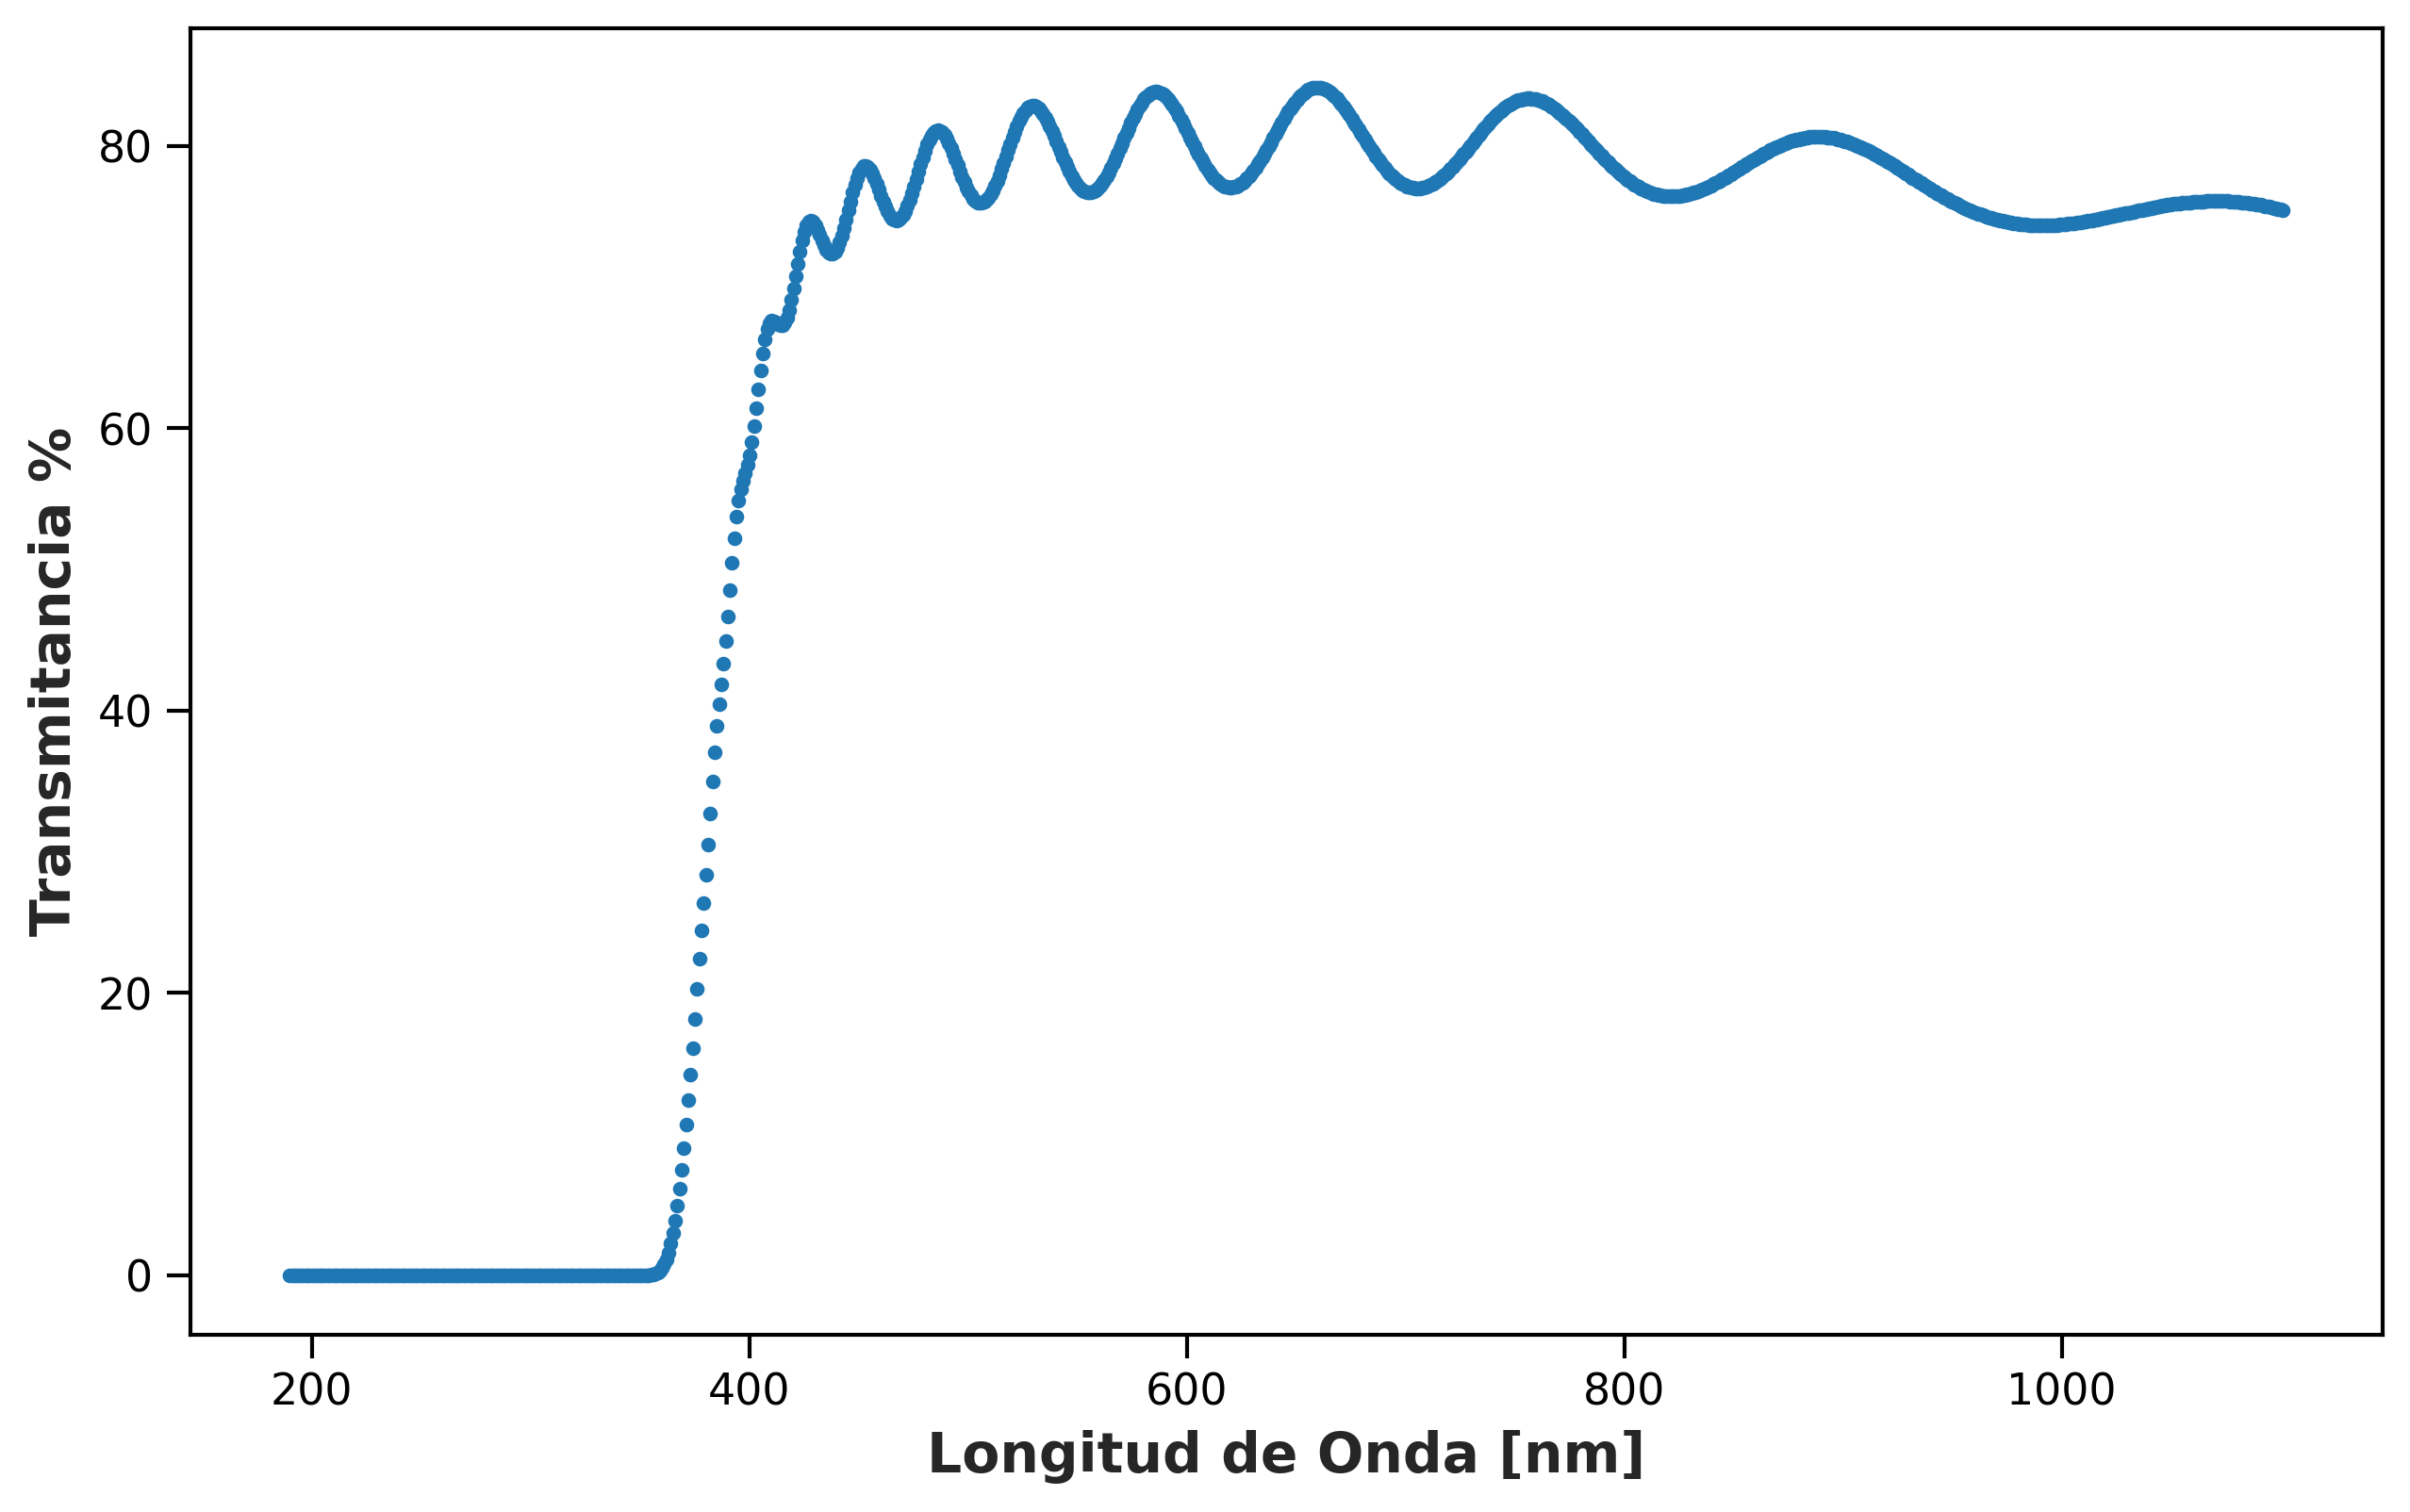

In [54]:
n = random.randint(0, df_final.shape[0]-1)
plot_unico(x, df_final['Espectro'][n])

# Save DF

In [55]:
df_final.shape

(240000, 7)

In [56]:
df_final.to_parquet(main_path + '/notebooks/3_data_simulation/NewDataAzONetV2/bin_{}.parquet'.format(bint), index = False)